<a href="https://colab.research.google.com/github/ManoloVM21/MachineLearningTeam4/blob/main/notebooks/starter_housing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

from xgboost import XGBRegressor


In [22]:

# =========================
# Load Data
# =========================
housing = pd.read_csv(
  "https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/housing.csv"
)

incomes_df = pd.read_csv("transposed_income_by_zip.csv")

# --- Add 'selled_again' feature ---
id_counts = housing['id'].value_counts()
housing['selled_again'] = housing['id'].map(id_counts).apply(lambda x: 1 if x > 1 else 0)
# ----------------------------------

#housing = housing[housing['sqft_living'] < 12000]
#housing = housing[housing['sqft_lot'] < 600000]
housing = housing[housing['bathrooms'] < 3]
housing = housing.drop_duplicates(subset=['id'])
#housing = housing[housing['sqft_basement'] < 2000]
#housing = housing[housing['condition'] > 2]

# --- Remove price outliers based on 2 standard deviations ---
mean_price = housing['price'].mean()
std_price = housing['price'].std()
upper_bound = mean_price + 2 * std_price
lower_bound = mean_price - 2 * std_price
housing = housing[(housing['price'] >= lower_bound) & (housing['price'] <= upper_bound)]
# ------------------------------------------------------------

seattle_offices = [
    {
        "name": "Amazon HQ - Doppler Building",
        "company": "Amazon",
        "latitude": 47.615257,
        "longitude": -122.338356
    },
    {
        "name": "Starbucks Headquarters",
        "company": "Starbucks",
        "latitude": 47.618064,
        "longitude": -122.303796
    },
    {
        "name": "Microsoft Headquarters",
        "company": "Microsoft",
        "latitude": 47.643543,
        "longitude": -122.130821
    },
    {
        "name": "Google Seattle Campus (South Lake Union)",
        "company": "Google",
        "latitude": 47.622900,
        "longitude": -122.336600
    },
    {
        "name": "Meta (Facebook) Seattle Office",
        "company": "Meta",
        "latitude": 47.623500,
        "longitude": -122.336500
    },
    {
        "name": "Zillow Headquarters",
        "company": "Zillow",
        "latitude": 47.620500,
        "longitude": -122.338000
    },
    {
        "name": "Expedia Group Headquarters (Bellevue)",
        "company": "Expedia",
        "latitude": 47.610100,
        "longitude": -122.201500
    }
]
from geopy.distance import great_circle

def calculate_distance(point1_lat, point1_long, point2_lat, point2_long):
    """Calculates the Haversine (great_circle) distance between two points."""
    point1 = (point1_lat, point1_long)
    point2 = (point2_lat, point2_long)
    return great_circle(point1, point2).km
for office in seattle_offices:
    company_name = office['company']
    office_lat = office['latitude']
    office_long = office['longitude']

    # Create a new column for the distance to this company
    housing[f'distance_to_{company_name}'] = housing.apply(
        lambda row: calculate_distance(row['lat'], row['long'], office_lat, office_long),
        axis=1
    )
seattle_water_bodies = [
    {
        "name": "Lake Union",
        "latitude": 47.6401,
        "longitude": -122.3366
    },
    {
        "name": "Lake Washington",
        "latitude": 47.6099,
        "longitude": -122.2155
    },
    {
        "name": "Puget Sound",
        "latitude": 47.6062,
        "longitude": -122.6035
    },
    {
        "name": "Green Lake",
        "latitude": 47.6749,
        "longitude": -122.3364
    },
    {
        "name": "Mercer Slough",
        "latitude": 47.5750,
        "longitude": -122.1950
    },
    {
        "name": "Elliott Bay",
        "latitude": 47.6111,
        "longitude": -122.3450
    }
]
min_distances_to_water = []

for index, row in housing.iterrows():
    house_lat = row['lat']
    house_long = row['long']

    distances_to_all_water_bodies = []
    for water_body in seattle_water_bodies:
        water_lat = water_body['latitude']
        water_long = water_body['longitude']
        distance = calculate_distance(house_lat, house_long, water_lat, water_long)
        distances_to_all_water_bodies.append(distance)

    min_distances_to_water.append(min(distances_to_all_water_bodies))

housing['distance_to_water'] = min_distances_to_water

X = housing.drop(columns=["price"])
y = housing["price"]


In [23]:
# =========================
# Custom Transformer
# =========================
class HousingFeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, income_df):
        self.income_df = income_df

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        df = X.copy()

        # Convert 'date' to datetime and extract features
        df['date'] = pd.to_datetime(df['date'], format='%Y%m%dT%H%M%S')
        df['sale_year'] = df['date'].dt.year
        df['sale_month'] = df['date'].dt.month
        df['house_age_at_sale'] = df['sale_year'] - df['yr_built']

        # Merge income data
        df = pd.merge(
            df,
            self.income_df[['zipcode', 'number_of_houses', 'mean_income']],
            on='zipcode',
            how='left'
        )

        # Drop unused columns
        df = df.drop(columns=[
            "id",'date' # 'id' and 'date' are now explicitly dropped after processing
        ])
        # 'zipcode' is no longer one-hot encoded here; it will be handled by ColumnTransformer
        return df


In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
# =========================
# Train-Test Split
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [26]:
# =========================
# Define preprocessing steps with ColumnTransformer
# =========================
from sklearn.impute import SimpleImputer # Added import for SimpleImputer

# Apply the custom feature engineer first to get the final features list
# This temporary transformation helps identify features for ColumnTransformer
feature_engineer_temp = HousingFeatureEngineer(incomes_df)
X_train_transformed_temp = feature_engineer_temp.fit_transform(X_train)

# Identify numerical and categorical columns for ColumnTransformer
# 'zipcode' is now an integer, so it's a numerical column that needs one-hot encoding.
# All other columns are numerical and need scaling.

numerical_features = X_train_transformed_temp.select_dtypes(include=np.number).columns.tolist()
categorical_features = ['zipcode'] # Explicitly handle zipcode as categorical for OHE

# Remove 'zipcode' from numerical_features if it was included
if 'zipcode' in numerical_features:
    numerical_features.remove('zipcode')

# Create a pipeline for numerical features including imputation and scaling
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')), # Impute NaN values (introduced by pd.to_numeric errors='coerce')
    ('scaler', StandardScaler())
])

# Create the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features), # Use the numerical_transformer pipeline
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), categorical_features)
    ],
    remainder='passthrough' # Keep other columns (if any) as they are
)


In [27]:
# =========================
# Pipeline
# =========================
pipeline = Pipeline(steps=[
    ("feature_engineering", HousingFeatureEngineer(incomes_df)), # Custom feature engineering
    ('preprocessor', preprocessor), # Scaling and One-Hot Encoding
    ("model", XGBRegressor(
        n_estimators=5000,
        learning_rate=0.02,
        max_depth=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ))
])

In [28]:

# =========================
# Train
# =========================
pipeline.fit(X_train, y_train)


Pipeline(steps=[('feature_engineering',
                 HousingFeatureEngineer(income_df=    zipcode  number_of_houses  mean_income
0     98001             11109        85389
1     98002             12687        54713
2     98003             17791        61010
3     98004             15518       148860
4     98005              7507       128845
..      ...               ...          ...
65    98177              7797       124737
66    98178              8922        74831
67    98188              9610        57503
68    98198             13126        70268
69    98199              9173       126065

[70 rows x 3 columns])),
                ('preprocessor',
                 ColumnTransformer(remainder='pass...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.02,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=5, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=5000, n_jobs=None,
                              num_parallel_tree=None, ...))])

In [29]:
# =========================
# Evaluate
# =========================
y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}")
print(f"R²: {r2:.4f}")


RMSE: 59788.3371
R²: 0.8913


In [30]:
# =========================
# Feature Importances
# =========================
model = pipeline.named_steps["model"]

# Get feature names after preprocessing
# First, get feature names from the numerical transformer
num_feature_names = numerical_features

# Then, get feature names from the one-hot encoder
cat_feature_names = pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)

# Combine all feature names
processed_feature_names = list(num_feature_names) + list(cat_feature_names)

importance_df = pd.DataFrame({
    "Feature": processed_feature_names,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop 10 Feature Importances:")
print(importance_df.head(10))


Top 10 Feature Importances:
                  Feature  Importance
30            mean_income    0.124384
13                    lat    0.108710
8                   grade    0.094611
2             sqft_living    0.063443
6                    view    0.033924
25      distance_to_water    0.032560
5              waterfront    0.030518
33          zipcode_98004    0.028322
22       distance_to_Meta    0.022247
20  distance_to_Microsoft    0.021876


In [31]:
holdout_mini = pd.read_csv(
    "https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/housing_holdout_test_mini.csv"
)

holdout_mini.head()


,id,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,930000305,20141110T000000,4,1.75,2120,7680,1.0,0,0,4,7,1060,1060,1950,0,98177,47.7172,-122.361,1530,7680
1,9541600015,20150211T000000,4,2.25,2010,15375,1.0,0,0,4,8,2010,0,1957,0,98005,47.5956,-122.174,1930,15375
2,7338000150,20150129T000000,2,1.00,1070,4200,1.0,0,0,4,6,1070,0,1983,0,98002,47.3336,-122.215,1150,4200
3,6113400046,20140723T000000,4,2.50,1890,15770,2.0,0,0,4,7,1890,0,1968,0,98166,47.4281,-122.343,2410,15256
4,291310170,20140804T000000,3,2.50,1600,2610,2.0,0,0,3,8,1600,0,2005,0,98027,47.5344,-122.068,1445,1288


In [32]:
import pandas as pd
from geopy.distance import great_circle

# --- Load holdout ---
holdout_mini = pd.read_csv(
    "https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/housing_holdout_test_mini.csv"
)

# --- Add selled_again (same logic you used on training) ---
id_counts_holdout = holdout_mini["id"].value_counts()
holdout_mini["selled_again"] = holdout_mini["id"].map(id_counts_holdout).apply(lambda x: 1 if x > 1 else 0)

# --- Same office list you used in training ---
seattle_offices = [
    {"company": "Amazon",    "latitude": 47.615257, "longitude": -122.338356},
    {"company": "Starbucks", "latitude": 47.618064, "longitude": -122.303796},
    {"company": "Microsoft", "latitude": 47.643543, "longitude": -122.130821},
    {"company": "Google",    "latitude": 47.622900, "longitude": -122.336600},
    {"company": "Meta",      "latitude": 47.623500, "longitude": -122.336500},
    {"company": "Zillow",    "latitude": 47.620500, "longitude": -122.338000},
    {"company": "Expedia",   "latitude": 47.610100, "longitude": -122.201500},
]

def dist_km(lat1, lon1, lat2, lon2):
    return great_circle((lat1, lon1), (lat2, lon2)).km

# --- Add distance-to-office features ---
for office in seattle_offices:
    company = office["company"]
    lat2, lon2 = office["latitude"], office["longitude"]
    holdout_mini[f"distance_to_{company}"] = holdout_mini.apply(
        lambda row: dist_km(row["lat"], row["long"], lat2, lon2),
        axis=1
    )

# --- Same water bodies list you used in training ---
seattle_water_bodies = [
    {"name": "Lake Union",     "latitude": 47.6401, "longitude": -122.3366},
    {"name": "Lake Washington","latitude": 47.6099, "longitude": -122.2155},
    {"name": "Puget Sound",    "latitude": 47.6062, "longitude": -122.6035},
    {"name": "Green Lake",     "latitude": 47.6749, "longitude": -122.3364},
    {"name": "Mercer Slough",  "latitude": 47.5750, "longitude": -122.1950},
    {"name": "Elliott Bay",    "latitude": 47.6111, "longitude": -122.3450},
]

# --- Add distance_to_water (min distance to any water body) ---
holdout_mini["distance_to_water"] = holdout_mini.apply(
    lambda row: min(
        dist_km(row["lat"], row["long"], wb["latitude"], wb["longitude"])
        for wb in seattle_water_bodies
    ),
    axis=1
)


In [33]:
holdout_preds = pipeline.predict(holdout_mini)


In [34]:
submission = pd.DataFrame({
    "price": holdout_preds
})


In [35]:
submission.to_csv("team4-module3-predictions.csv", index=False)


Full Metric Set

In [36]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred = pipeline.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"RMSE: ${rmse:,.2f}")
print(f"MAE:  ${mae:,.2f}")
print(f"R²:   {r2:.4f}")
print(f"MAPE: {mape:.2f}%")


RMSE: $59,788.34
MAE:  $42,280.09
R²:   0.8913
MAPE: 10.59%


Bias Check

In [37]:
residuals = y_test - y_pred

print(f"Mean Residual (Bias): {residuals.mean():,.2f}")
print(f"Median Residual:      {np.median(residuals):,.2f}")


Mean Residual (Bias): -1,532.12
Median Residual:      -610.83


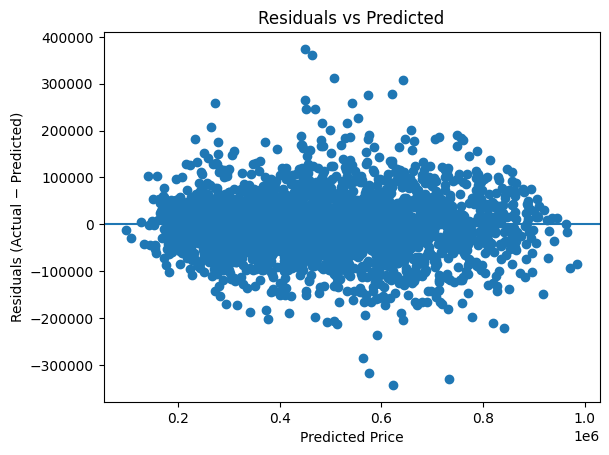

In [39]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted Price")
plt.ylabel("Residuals (Actual − Predicted)")
plt.title("Residuals vs Predicted")
plt.show()


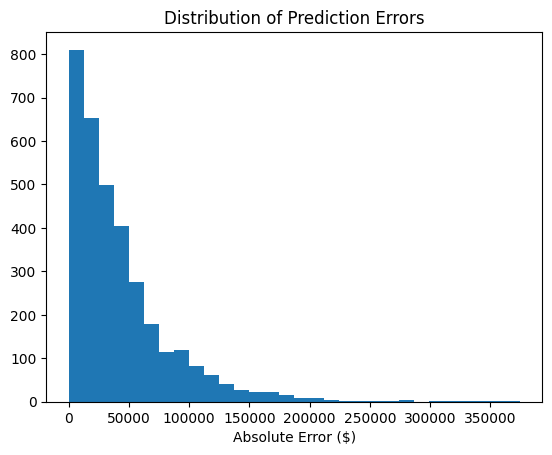

In [40]:
plt.figure()
plt.hist(np.abs(residuals), bins=30)
plt.xlabel("Absolute Error ($)")
plt.title("Distribution of Prediction Errors")
plt.show()


In [41]:
import pandas as pd

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results["AbsError"] = np.abs(results["Actual"] - results["Predicted"])
results["PctError"] = results["AbsError"] / results["Actual"] * 100

results["Tier"] = pd.qcut(
    results["Actual"],
    q=4,
    labels=["Low", "Mid", "High", "Luxury"]
)

tier_metrics = results.groupby("Tier").agg({
    "AbsError": ["mean", "median"],
    "PctError": "mean",
    "Actual": "count"
})

print(tier_metrics)


            AbsError                PctError Actual
                mean       median       mean  count
Tier                                               
Low     35480.030869  23304.53125  16.122231    841
Mid     33963.554779  24621.90625   9.299649    850
High    43201.968037  33127.28125   8.894147    833
Luxury  56589.584487  42425.15625   8.051642    840


/tmp/ipython-input-677527438.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tier_metrics = results.groupby("Tier").agg({
